# Basic Networks

The general procedure for creating a network is:

* Create one or more {py:obj}`Library <pynucastro.rates.library.Library>` objects containing the rates that you want.
  This can start with a list of nuclei or a list of rate names (like `"c12(a,g)o16"`).

  There are multiple sources of rates in pynucastro, so sometimes several libraries will be created,
  filtering the desired rates from the different sources.
  
* Remove any duplicate rates between the libraries.  Usually this means keeping tabulated rates over ReacLib rates, since the tabulated
  rates are more general.

* Rederive the inverse rates from ReacLib using detailed balance.

* Create a network using either {py:obj}`RateCollection <pynucastro.networks.rate_collection.RateCollection>` or one of the classes derived from it.

* Approximate some of the nuclei out of the network by introducing $(\alpha, p)(p,\gamma)$ or other rate approximations.

pynucastro gives you control over each of these steps, which is needed for some complex network types. But if you just want to create a network that has all possible links connecting a set of nuclei, then the
{py:func}`network_helper <pynucastro.networks.helper.network_helper>` function is enough.

```{tip}
You can pass in the names of individual nuclei, or a range of nuclei, like ``"ni56-58"``, or a comma-separated group of the same element, like ``"ni56,58,60"``.
```

Here's an example of a CNO network with some breakout.

In [1]:
import pynucastro as pyna

In [2]:
nuclei = ["p", "he4",
          "c12-13", "n13-15", "o14-18",
          "f17-19", "ne18-21"]
net = pyna.network_helper(nuclei)

```{tip}
By default, `network_helper` will create a {py:obj}`PythonNetwork <pynucastro.networks.python_network.PythonNetwork>`, but
this can be changed via the `network_type` argument.
```

In [3]:
type(net)

pynucastro.networks.python_network.PythonNetwork

By default, `network_helper` will look at both {py:obj}`ReacLibLibrary <pynucastro.rates.library.ReacLibLibrary>` and {py:obj}`TabularWeakLibrary <pynucastro.rates.library.TabularWeakLibrary>` to find rates.  The warnings we see above about not being able to link nuclei are from the `TabularWeakLibrary`, since those nuclei do not have tabulated weak rates.

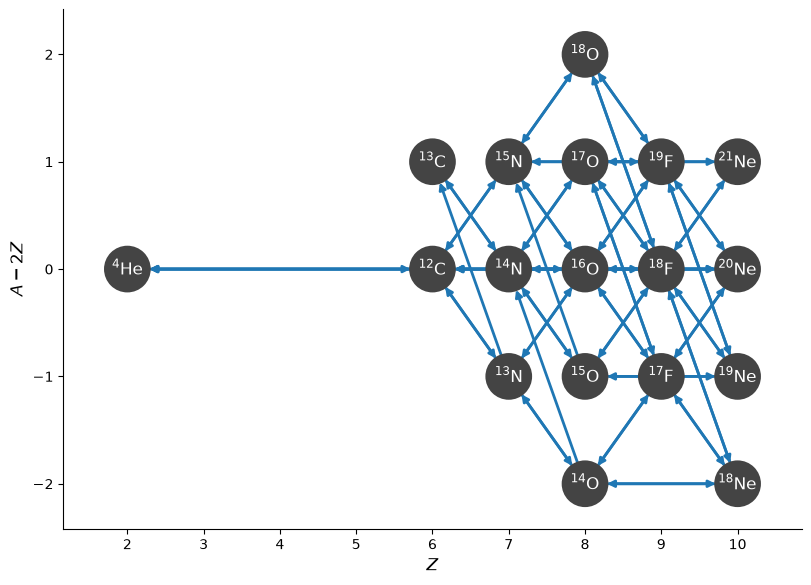

In [4]:
fig = net.plot(rotated=True)

We can see that it is using some tabulated weak rates for some links:

In [5]:
net.summary()

Network summary
---------------
  explicitly carried nuclei: 19
  approximated-out nuclei: 0
  inert nuclei (included in carried): 0

  NSE compatible? False

  total number of rates: 69

  rates explicitly connecting nuclei: 69
  hidden rates: 0

  reaclib rates: 32
  starlib rates: 0
  temperature tabular rates: 0
  weak tabular rates: 8
  approximate rates: 0
  derived rates: 29
  branched rates: 0
  modified rates: 0
  custom rates: 0


We can highlight these weak rates in the plot

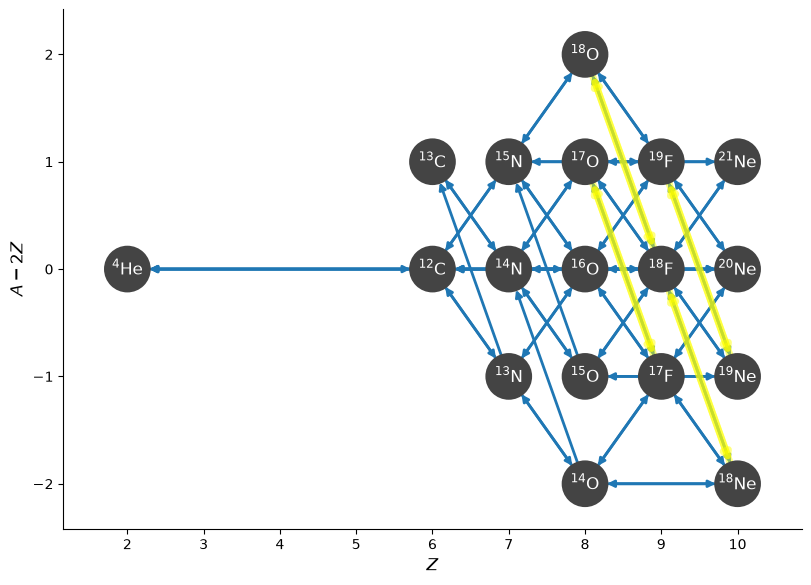

In [6]:
fig = net.plot(rotated=True,
               highlight_filter_function=lambda r: isinstance(r, pyna.rates.TabularWeakRate))

Also notice that `network_helper` includes both the forward and reverse rates for all links. 

The notebooks following show how to have finer control when creating a network, allowing you to manually filter rates from libraries, remove duplicates, compute reverse rates, and introduce approximations.